# Report Visualisations

In [2]:
import sys
import pathlib
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Add src/ to path so data_loaders is importable
ROOT = pathlib.Path.cwd().parent   # notebooks/ -> project root
sys.path.insert(0, str(ROOT / "src"))

from data_loaders import load_cpih_monthly, load_cpih_fy_indices, load_lcf_shares

OUTPUT = ROOT / "data" / "output"
%matplotlib inline

In [3]:
plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
    "font.size":         9,
    "axes.titlesize":    11,
    "figure.dpi":        150,
})

TENURE_4 = ["social_rent", "private_rent", "own_outright", "own_mortgage"]

TENURE_LABELS = {
    "social_rent":  "Social Rent",
    "private_rent": "Private Rent",
    "own_outright": "Own Outright",
    "own_mortgage": "Own Mortgage",
}

TENURE_COLOURS = {
    "social_rent":  "#1b9e77",
    "private_rent": "#d95f02",
    "own_outright": "#7570b3",
    "own_mortgage": "#e7298a",
}

COICOP_MAP = {
    "share_01_food_non_alcoholic":  "Food",
    "share_02_alcohol_tobacco":     "Alcohol & Tobacco",
    "share_03_clothing_footwear":   "Clothing",
    "share_04_housing_fuel_power":  "Housing & Utilities",
    "share_05_furnishings":         "Furnishings",
    "share_06_health":              "Health",
    "share_07_transport":           "Transport",
    "share_08_communication":       "Communication",
    "share_09_recreation_culture":  "Recreation",
    "share_10_education":           "Education",
    "share_11_restaurants_hotels":  "Restaurants",
    "share_12_misc_goods_services": "Misc. Goods",
}

OFFICIAL_COICOP = list(COICOP_MAP.keys())
share_cols = OFFICIAL_COICOP

In [4]:
shares = load_lcf_shares()
monthly = load_cpih_monthly()
fy_index = load_cpih_fy_indices()

# archetype_name, archetype_value, year, inflation_rate
group_inflation = pd.read_csv(OUTPUT / "group_inflation_rates.csv")

# archetype name, archetype value, year, COICOP label, contribution
coicop_contributions = pd.read_csv(OUTPUT / "inflation_decomposition.csv")

print("These are the shapes of each database (for debugging):")
print(f"- LCF shares: {shares.shape}")
print(f"- CPIH monthly: {monthly.shape}")
print(f"- CPIH FY index: {fy_index.shape}")
print(f"- Inflation: {group_inflation.shape}")
print(f"- Decomposition: {coicop_contributions.shape}")

These are the shapes of each database (for debugging):
- LCF shares: (45500, 23)
- CPIH monthly: (458, 20)
- CPIH FY index: (9, 17)
- Inflation: (135, 4)
- Decomposition: (1890, 5)


#### Figure 2: Data quality audit
- (a) How much data is genuinely missing per column?

- (b) How many households report 0 spending per COICOP division?
Note: This is not a data quality issue but reflects that LCF is a biweekly diary where households may have reasons for 0 spending in a category (most households don't pay for education or tobacco every 2 weeks).

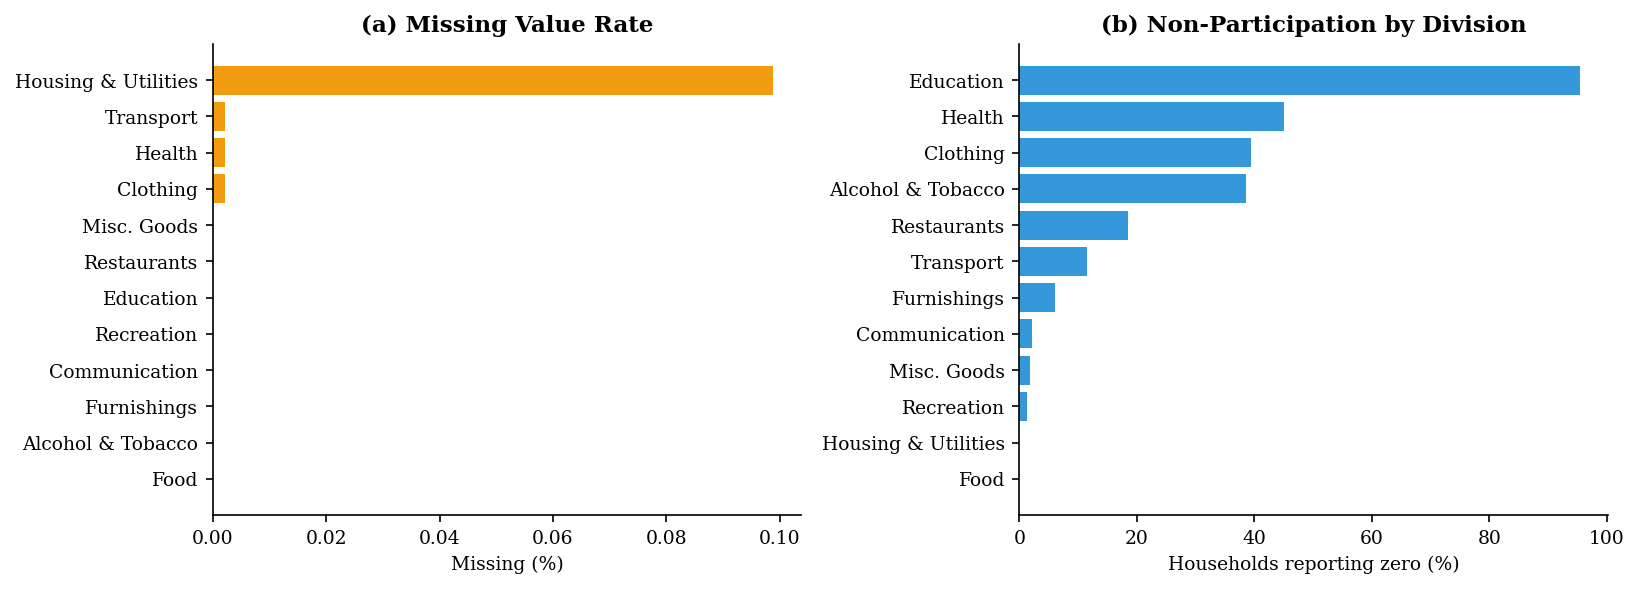

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Missing value rate for each COICOP division
missing_rates = (shares[share_cols].isnull().sum() / len(shares) * 100).sort_values()
missing_values_labels = [COICOP_MAP.get(c, c) for c in missing_rates.index]
colours = ["#E74C3C" if v > 1 else "#F39C12" if v > 0 else "#27AE60" for v in missing_rates.values]
ax1.barh(missing_values_labels, missing_rates.values, color=colours)
ax1.set_xlabel("Missing (%)")
ax1.set_title("(a) Missing Value Rate", weight="bold")

# (b) Non-participation for each COICOP division
zero_pct = ((shares[share_cols] == 0).sum() / len(shares) * 100).sort_values()
zero_labels = [COICOP_MAP.get(c, c) for c in zero_pct.index]
ax2.barh(zero_labels, zero_pct.values, color="#3498DB")
ax2.set_xlabel("Households reporting zero (%)")
ax2.set_title("(b) Non-Participation by Division", weight="bold")

plt.tight_layout()
plt.show()


Fig. 2 audits data completeness and expenditure prevalence across the 12 COICOP divisions. Fig. 2A confirms that missingness is negligible: only Housing & Utilities exhibits any notable missing values (0.10%), with all other divisions at or below 0.01%. This reflects that LCF is designed as a structured diary where households record expenditure against pre-defined COICOP categories.

Fig. 2B distinguishes a lack of purchasing from data quality failures in certain categories. High zero-expenditure rates in Education (95.5%), Health (45.1%), and Clothing (39.4%) are expected: most households do not pay for private school or private healthcare at all, let alone within the two-week diary window. Clothing purchases were also infrequent within a two-week window. In contrast, essential categories such as Food (0.04%) and Housing & Utilities (0.2%) are nearly universal. Households reporting zero in these divisions likely submitted an incomplete diary. Consequently, these cases are removed during filtering: 296 for zero food, 50 for zero housing, and 7 for negative total expenditure. In total, 350 households (0.76% of the sample) were removed.

Post-filtering, expenditure shares sum to exactly 1.0 for all 45,500 households.

#### Data preparation

This project relies on two data sets. The Living Costs and Food Survey (LCF) has demographic and expenditure data for each COICOP category at a household-level; it’s available via the UK Data Service and is used to construct our ‘spending baskets’ for each housing tenure. The ONS MM23 supplies the CPIH price indices for each COICOP category, price indices for various subcategories within each COICOP category and an ‘All items CPIH Index’ headline inflation rate.

#### LCF Microdata
The LCF is an expenditure survey for households conducted continuosly in the form of a biweekly expenditure diary. Each year, a fresh sample of around 5000 UK households per year.




Tenure	        Min cell	Max cell
Own Mortgage	1,727	    2,317
Own Outright	1,237	    1,788
Private Rent	585	        849
Social Rent	    550	        865

#### Figure 3, Distribution of COICOP Expenditure Shares
- (a) Boxplots showing the spread of each COICOP share across all households
- (b) Skewness and Kurtosis per share.


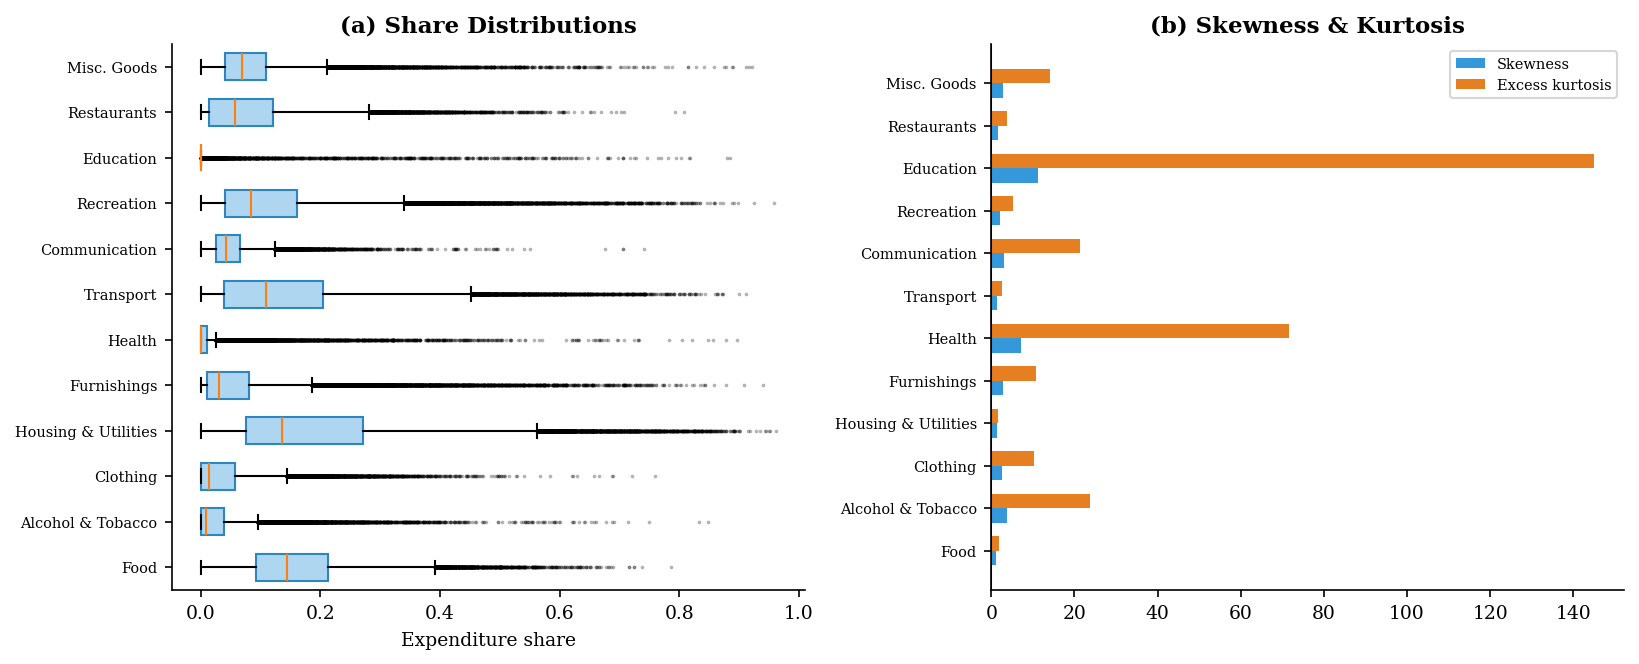

In [6]:
share_data = shares[share_cols].dropna()
short = [COICOP_MAP.get(c, c) for c in share_cols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# LHS: Boxplots
bp = ax1.boxplot([share_data[c].values for c in share_cols],
                 vert=False, patch_artist=True, widths=0.6,
                 flierprops=dict(marker=".", markersize=1.5, alpha=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor("#AED6F1")
    patch.set_edgecolor("#2E86C1")
ax1.set_yticklabels(short, fontsize=7)
ax1.set_xlabel("Expenditure share")
ax1.set_title("(a) Share Distributions", weight="bold")

# RHS: Skewness & kurtosis
skew = [share_data[c].skew() for c in share_cols]
kurt = [share_data[c].kurtosis() for c in share_cols]
y = np.arange(len(share_cols))
ax2.barh(y - 0.17, skew, height=0.34, color="#3498DB", label="Skewness")
ax2.barh(y + 0.17, kurt, height=0.34, color="#E67E22", label="Excess kurtosis")
ax2.set_yticks(y)
ax2.set_yticklabels(short, fontsize=7)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.legend(fontsize=7)
ax2.set_title("(b) Skewness & Kurtosis", weight="bold")

plt.tight_layout()
plt.show()



(A) reveals considerable variation in spread of expenditure shares across COICOP divisions across all 45,500 households. Food and Housing & Utilities show the highest median shares - consistent with being essential spending categories. In contrast, Education and Health are concentrated near 0% with a long right tail: some households allocate upwards of 10% of expenditure to Education. Public school and the NHS are widely used with a minority of households using private school or healthcare. Housing & Utilities show the widest IQR, highlighting the structural divide between renters and outright owners.

(B) further explains this asymmetry. Education, Health and Alcohol and Tobacco are most skewed (>2), confirming the long right tails in the boxplots. These categories show elevated excess kurtosis, indicating extreme values are more common than a normal distribution would predict. Food and Housing and Utilities are nearly symmetric, as they are universal expenditure categories for almost all households.

Households were only removed if they had zero spending on essential categories (categories where zero spending is implausible) or negative total spending, as this reflects an incomplete expenditure diary. 296 with zero food expenditure, 50 with zero housing expenditure and 7 with negative total spending were removed. The heavily right-skewed distributions in categories like Education and Health are not outliers; they reflect genuine spending heterogeneity among households. Z-score filtering was considered but is unsuitable: with Education's mean near zero and 95.5% of households reporting no spending, any household paying tuition fees would be flagged as extreme despite representing a legitimate subpopulation. Winsorisation was also considered but is incompatible with compositional data: expenditure shares must sum to 1.0 per household, and capping one share breaks this constraint. Redistributing the clipped amount across the remaining categories would require an arbitrary allocation rule that distorts the Laspeyres weights.

In [7]:
'''
References:
- 6-7% of pupils attend private schools in the UK:
https://ifs.org.uk/publications/tax-private-school-fees-and-state-school-spending
- 
'''

'\nReferences:\n- 6-7% of pupils attend private schools in the UK:\nhttps://ifs.org.uk/publications/tax-private-school-fees-and-state-school-spending\n- \n'

#### Table II: Summary Statistics by Tenure

Weighted means of key expenditure shares and income, disaggregated by tenure group.
Shows the structural differences in household budgets that drive differential inflation.

In [8]:
def compute_weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

tenure_groups = [("All households", shares)]
for tenure in TENURE_4:
    tenure_groups.append((TENURE_LABELS[tenure], shares[shares["tenure_type"] == tenure]))

rows = []
for group_name, group_data in tenure_groups:
    household_weights = group_data["household_weight"] if "household_weight" in group_data else pd.Series(1.0, index=group_data.index)

    row = {"Group": group_name, "N": f"{len(group_data):,}"}
    row["Food %"]       = f"{compute_weighted_mean(group_data['share_01_food_non_alcoholic'], household_weights) * 100:.1f}"
    row["Energy %"]     = f"{compute_weighted_mean(group_data['share_04_energy_other'], household_weights) * 100:.1f}"
    row["Rent %"]       = f"{compute_weighted_mean(group_data['share_04_actual_rent'], household_weights) * 100:.1f}"
    row["Transport %"]  = f"{compute_weighted_mean(group_data['share_07_transport'], household_weights) * 100:.1f}"
    row["Recreation %"] = f"{compute_weighted_mean(group_data['share_09_recreation_culture'], household_weights) * 100:.1f}"
    
    if "income_gross_weekly" in group_data:
        row["Gross £/wk"] = f"{compute_weighted_mean(group_data['income_gross_weekly'], household_weights):.0f}"
    
    rows.append(row)

summary_table = pd.DataFrame(rows)
summary_table

,Group,N,Food %,Energy %,Rent %,Transport %,Recreation %,Gross £/wk
0,All households,"45,500",16.0,12.9,8.6,13.7,11.9,729
1,Social Rent,"6,442",18.4,15.2,18.0,8.6,9.0,427
2,Private Rent,"6,763",12.4,9.9,32.2,10.6,7.4,681
3,Own Outright,"14,001",15.2,11.1,0.0,18.1,13.5,994
4,Own Mortgage,"17,874",17.3,14.9,0.3,13.6,14.0,661


Table II: Weighted mean expenditure shares (%) and gross weekly income by tenure group, pooled across 2015/16--2023/24. Means are weighted using LCF survey grossing weights. N denotes unweighted household-year observations. Mortgagor shares are computed over COICOP consumption expenditure, which excludes mortgage payments; their non-housing shares are therefore inflated relative to renters, whose housing costs enter the denominator directly.


#### Figure 4: Tenure Basket Deviation from Pooled Mean
- Heatmap showing how each tenure group's spending deviates from the overall average.
- Bold values = deviation in percentage points, parentheses = raw share.
- This is the central EDA figure — it shows *where* tenure groups differ, not just *that* they differ.

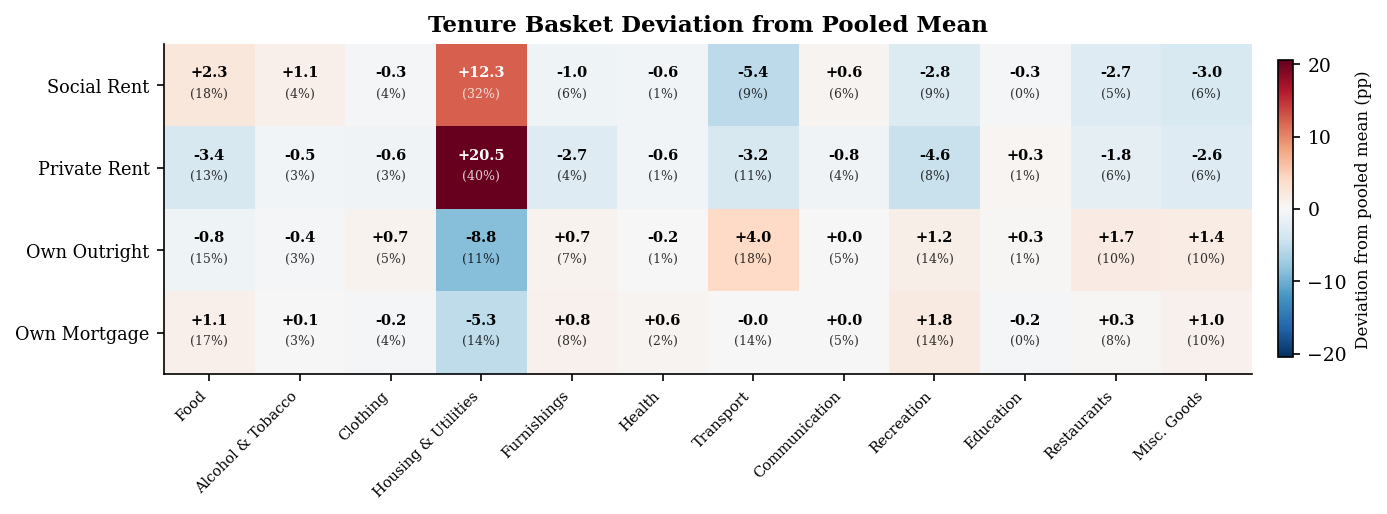

In [9]:
sub = shares[shares["tenure_type"].isin(TENURE_4)]

# Pooled mean across all tenure groups
pooled_mean = sub[share_cols].mean()

# Mean per tenure group
tenure_means = sub.groupby("tenure_type")[share_cols].mean()
tenure_means = tenure_means.loc[TENURE_4]  # enforce row order

# Deviation in percentage points
deviation = (tenure_means - pooled_mean) * 100
raw_pct = tenure_means * 100

# Each row is a tenure type, each column is a COICOP division.
row_labels = [TENURE_LABELS[t] for t in tenure_means.index]
col_labels = [COICOP_MAP[c] for c in share_cols]

fig, ax = plt.subplots(figsize=(10, 3.5))
colour_scale_max = max(np.abs(deviation.values).max(), 1.0)
im = ax.imshow(deviation.values, cmap="RdBu_r", vmin=-colour_scale_max, vmax=colour_scale_max, aspect="auto")

# Annotate each cell: bold deviation + raw share underneath
for i in range(deviation.shape[0]):
    for j in range(deviation.shape[1]):
        dev = deviation.values[i, j]
        raw = raw_pct.values[i, j]

        # Use white text if it gets dark
        colour = "white" if abs(dev) > colour_scale_max * 0.55 else "black"
        ax.text(j, i - 0.15, f"{dev:+.1f}", ha="center", va="center", fontsize=7, color=colour, weight="bold")
        ax.text(j, i + 0.1, f"({raw:.0f}%)", ha="center", va="center", fontsize=6, color=colour, alpha=0.8)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Deviation from pooled mean (pp)", fontsize=8)

ax.set_title("Tenure Basket Deviation from Pooled Mean", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()


Fig. 4 shows where different tenure types allocate spending compared to the pooled mean. Owner occupied and renting households spend a greater and lesser share of total expenditure on transport than the pooled average respectively. This mirrors the UK property market structure where private renters are disproportionately located in urban areas compared to owner-occupiers, who are more concentrated in suburban locations [1007]. However, the biggest source of expenditure variation is by far housing and utilities (COICOP 04). While private and social renters allocate 40% and 32% of total expenditure resp. to this category (20.5 and 12.3 pp above the pooled mean resp.), outright owners and mortgage owners sit 8.8pp and 5.3pp below the mean respectively. This gap reflects the COICOP expenditure guidelines, under which renters' full rent is recorded as a consumption expense, whereas mortgage payments are classified as investments and excluded. Thus, owner-occupiers' Housing and Utilities spending therefore captures only energy, maintenence, water and council tax. While this is in line with the EU Harmonised Index of Consumer Prices methodology [1010], we think this is a limitation as it suggests owner occupied househoulds with a morgage only pay a 3.5pp greater share of spending on housing and utilities than owner occupied households without - understating the difference. 

This deviation in expenditure share on baskets directly impact how households of different tenure types experience inflation differently. For example, the £2 bus fare cap in 2022 (and later £3 cap) was intended to target a low-income demographic [1008] but our data indicates that the deflationary impact of reducing transport fees in general will impact social renters the least out of any tenure type. Social renters are widely understood to be the lowest income tenure type [1009], suggesting a limitation in recent government policy.

The dominance of housing costs for renters produces a visible crowding-out effect in their baskets. Private renters fall below the pooled mean in ten of the remaining eleven divisions, with the largest deficits in Recreation (−4.6 pp), Food (−3.4 pp), and Transport (−3.2 pp). Social renters display a similar but less extreme compression, though they retain above-average Food (+2.3 pp) and Alcohol & Tobacco (+1.1 pp) shares — consistent with a lower-income demographic for whom necessities and habitual goods command a larger budget share even after housing costs.

References:
- [1008] Frontier Economics and SYSTRA, "Evaluation of the First 10 Months of the £2 Bus Fare Cap," Department for Transport, London, UK, May 2025. [Online]. Available: https://assets.publishing.service.gov.uk/media/681b355b9ef97b58cce3e4e0/evaluation-of-the-first-10-months-of-the-2-bus-fare-cap.pdf
- [1007] Ministry of Housing, Communities and Local Government, "English Housing Survey: Housing Stock Report," MHCLG, London, UK, 2014. Available: https://assets.publishing.service.gov.uk/media/5a805424ed915d74e33f9cc7/Housing_Stock_report.pdf
- [1009] "English Housing Survey 2023-24: rented sectors," Ministry of Housing, Communities & Local Government, Jul. 17, 2025, [Online]. Available: https://www.gov.uk/government/statistics/english-housing-survey-2023-to-2024-rented-sectors/english-housing-survey-2023-24-rented-sectors. [Accessed: Apr. 8, 2026].
- [1010] Office for National Statistics, "Consumer Prices Indices Technical Manual, 2019," 
    Rev. Mar. 2025. [Online]. Available: 
    https://www.ons.gov.uk/economy/inflationandpriceindices/methodologies/consumerpricesindicestechnicalmanual2019. 
    [Accessed: Apr. 9, 2026].

#### Figure 6: CPIH Sub-Index Time Series with Key Events

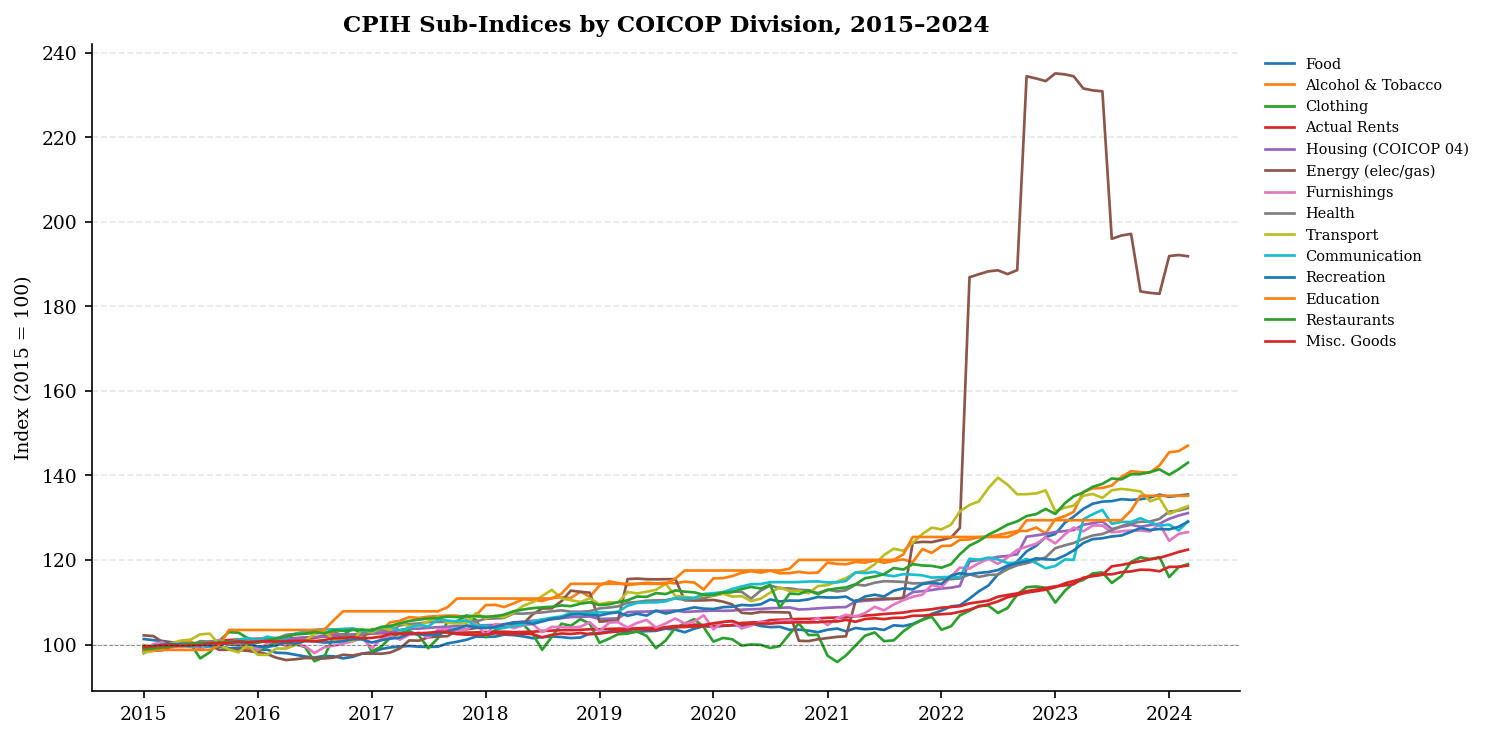

In [10]:
PRICE_MAP = {
    "food_non_alcoholic":    "Food",
    "alcohol_tobacco":       "Alcohol & Tobacco",
    "clothing_footwear":     "Clothing",
    "actual_rents":          "Actual Rents",
    "non_rent_housing_fuel": "Home Energy",
    "housing_fuel_power":    "Housing (COICOP 04)",
    "electricity_gas_fuels": "Energy (elec/gas)",
    "furnishings":           "Furnishings",
    "health":                "Health",
    "transport":             "Transport",
    "communication":         "Communication",
    "recreation_culture":    "Recreation",
    "education":             "Education",
    "restaurants_hotels":    "Restaurants",
    "misc_goods_services":   "Misc. Goods",
}
OFFICIAL_PRICE_NAMES = list(PRICE_MAP.keys())

price_cols = [c for c in OFFICIAL_PRICE_NAMES if c in monthly.columns]
sorted_monthly = monthly[(monthly["date"] >= "2015-01-01") & (monthly["date"] <= "2024-03-01")].sort_values("date")
fig, ax = plt.subplots(figsize=(10, 5))

for col in price_cols:
    label = PRICE_MAP.get(col, col)
    ax.plot(sorted_monthly["date"], sorted_monthly[col], linewidth=1.3, label=label)

ax.axhline(100, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.set_ylabel("Index (2015 = 100)")
ax.set_title("CPIH Sub-Indices by COICOP Division, 2015–2024", fontsize=11, weight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()



Fig. 6: 2015-2019 was a period of historically low inflation with headline CPIH remaining within the 0.4–2.6% range [11] and individual sub-indices moved broadly in step with limited dispersion around the headline rate. Crucially, When sub-indices move together, basket composition has little bearing on experienced inflation — regardless of how spending is allocated, all households face broadly the same price pressures.

From 2021, this pattern breaks. Energy prices surged to an index of approximately 235 by mid-2022 while actual rents remained below 115 — a gap of over 120 index points between two components that together form COICOP 04. Divergence in subindices prices makes the expenditure composition of a household much more consequential in how inflation impacts that household and makes average inflation estimates for a pooled mean household much less reliable. Private renters, who spend a much larger share of 'Housing and Utilities' cost on actual rent rather than energy, are largely shielded from the energy spike. Outright owners have the inverse relationship and were likely much more affected by the 2022 Energy Crisis. This divergence undermines the usefulness of a single headline inflation rate: during the 2022 energy crisis, the national CPIH reported one number, but the price shock experienced by an outright owner with high energy exposure bore little resemblance to that experienced by a private renter whose housing costs are predominantly rent.

- [11] Office for National Statistics, "Consumer Prices Indices Technical Manual, 2019," 
    Rev. Mar. 2025. [Online]. Available: 
    https://www.ons.gov.uk/economy/inflationandpriceindices/methodologies/consumerpricesindicestechnicalmanual2019. 
    [Accessed: Apr. 9, 2026].

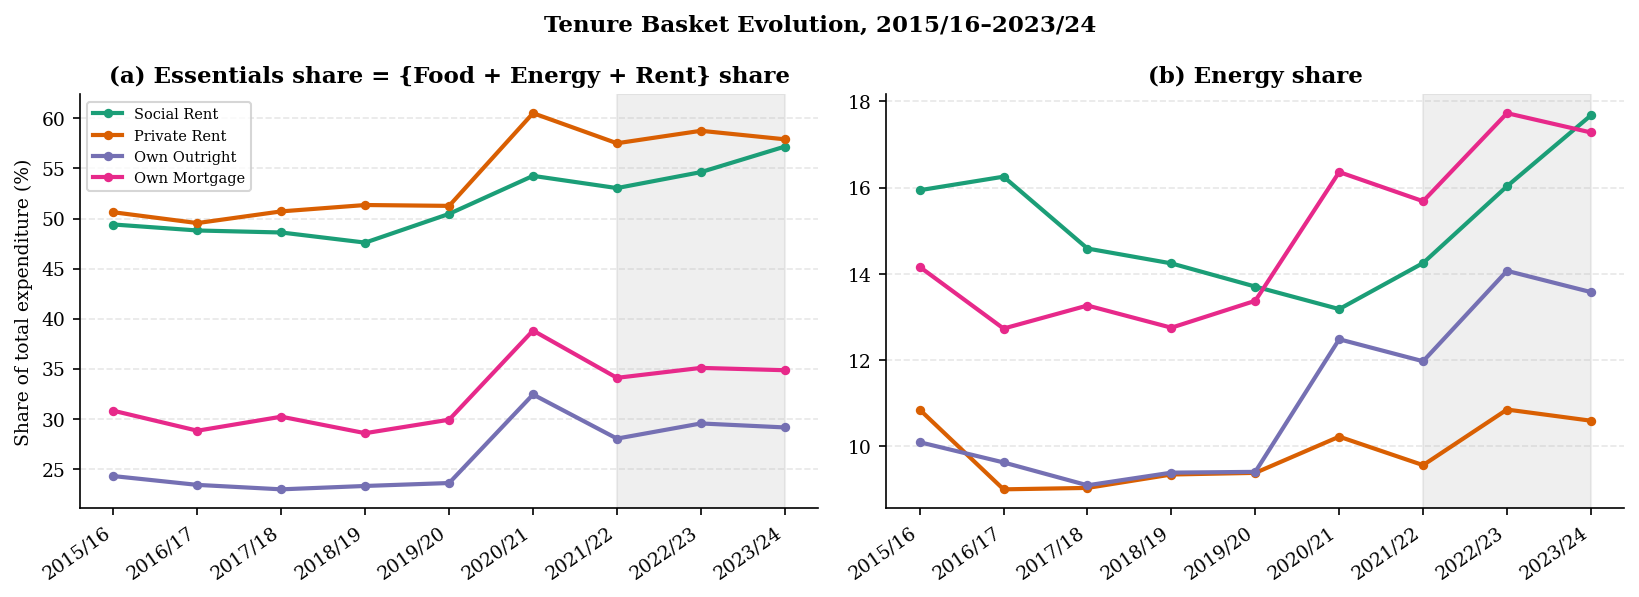

In [15]:
basket_data = shares[shares["tenure_type"].isin(TENURE_4)].copy()
basket_data["essentials"] = (basket_data["share_01_food_non_alcoholic"]
                           + basket_data["share_04_energy_other"]
                           + basket_data["share_04_actual_rent"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

years = sorted(basket_data["year"].unique())

for tenure in TENURE_4:
    tenure_data = basket_data[basket_data["tenure_type"] == tenure]
    
    essentials_by_year = []
    energy_by_year = []
    
    for year in years:
        year_data = tenure_data[tenure_data["year"] == year]
        if "household_weight" in year_data.columns:
            w = year_data["household_weight"].fillna(0)
            essentials_by_year.append(compute_weighted_mean(year_data["essentials"], w) * 100)
            energy_by_year.append(compute_weighted_mean(year_data["share_04_energy_other"], w) * 100)
        else:
            essentials_by_year.append(year_data["essentials"].mean() * 100)
            energy_by_year.append(year_data["share_04_energy_other"].mean() * 100)
    
    ax1.plot([y + 0.5 for y in years], essentials_by_year,
             color=TENURE_COLOURS[tenure], linewidth=2, marker="o",
             markersize=3.5, label=TENURE_LABELS[tenure])
    ax2.plot([y + 0.5 for y in years], energy_by_year,
             color=TENURE_COLOURS[tenure], linewidth=2, marker="o",
             markersize=3.5, label=TENURE_LABELS[tenure])

for ax in [ax1, ax2]:
    ax.axvspan(2021.5, 2023.5, color="grey", alpha=0.12)
    ax.set_xticks([y + 0.5 for y in years])
    ax.set_xticklabels([f"{y}/{str(y+1)[-2:]}" for y in years], rotation=35, ha="right")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

ax1.set_ylabel("Share of total expenditure (%)")
ax1.set_title(f"(a) Essentials share = {{Food + Energy + Rent}} share", weight="bold")
ax1.legend(fontsize=7)

ax2.set_title("(b) Energy share", weight="bold")

fig.suptitle("Tenure Basket Evolution, 2015/16–2023/24", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

Fig. 7A tracks the share of expenditure on essentials (defined as food, energy and rent). There's a clear persistent structural divide that spans nine years: social and private renters allocated over 50% of total expenditure to essentials, compared with a third for owner-occupied households. Between 2019/20 and 2023/24, the essentials share rose by approximately 5–7pp across all four tenure groups — expenditure that was previously available for discretionary spending was diverted to absorb the rising food and energy costs. While this compression of disposable budgets was similar for all households in pp, it occurred on top of an already unequal baseline with private renters reaching 58% of total expenditure on essentials by 2023/24. They had much less discretionary spending to absorb the inflation spike compared to households that own outright who faced the same shock from a baseline of 25% of spending on essentials. Thus, it's likely that the real-world effects of this discretionary squeeze (caused by the cost of living crisis) affected renters disproportionately. Crucially, this disproportionate impact on households is something one headline CPIH inflation rate can't show.

Since the energy price sub-index rose the fastest [Fig 6], its effect on expenditure shares for tenure types was seperated into the RHS chart. Although social renters typically live in homes with higher median EPC scores (70) than owner occupied homes (64)[1012], their share of energy spending rises most significantly. However, this is likely because they have the lowest total expenditure. Private renters seem least affected by the energy crisis, with energy share rising only 1.5pp from 2019-23, own outright households' energy share grew triple this in the same period. This is consistent with a subset of private renters that had utilities included in their rent, shielding them (and their recorded energy expenditure) from the price increase.

- [1012] Office for National Statistics, "Energy efficiency of housing in England and Wales: 2023," Nov. 1, 2023. [Online]. Available: https://www.ons.gov.uk/peoplepopulationandcommunity/housing/articles/energyefficiencyofhousinginenglandandwales/2023.[Accessed: Apr. 9, 2026].

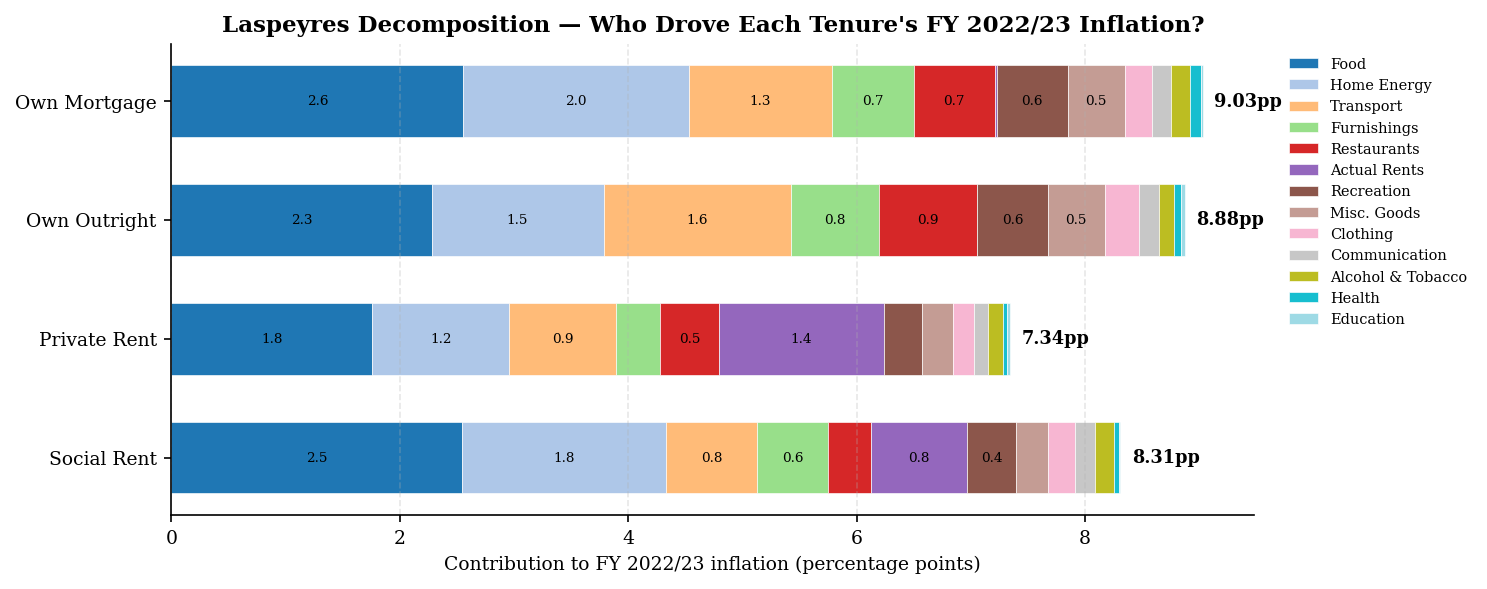

In [12]:
# Filter to tenure groups, crisis year, exclude the all_items summary row
crisis_decomp = coicop_contributions[
    (coicop_contributions["archetype_name"] == "tenure_type") &
    (coicop_contributions["year"] == 2022) &
    (coicop_contributions["coicop_label"] != "all_items")
].copy()

# Pivot to tenure x COICOP matrix
pivot = crisis_decomp.pivot_table(
    index="archetype_value",
    columns="coicop_label",
    values="contribution",
    aggfunc="first"
).fillna(0)

pivot = pivot.loc[[t for t in TENURE_4 if t in pivot.index]]

# Order columns by average contribution (biggest first)
col_order = pivot.mean().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 4))

row_labels = [TENURE_LABELS[t] for t in pivot.index]
y = np.arange(len(row_labels))
left = np.zeros(len(row_labels))

cmap = plt.get_cmap("tab20", len(col_order))

for i, col in enumerate(col_order):
    values = pivot[col].to_numpy()
    label = PRICE_MAP.get(col, col)
    ax.barh(y, values, left=left, height=0.6,
            color=cmap(i), edgecolor="white", linewidth=0.3, label=label)
    # Label segments larger than 0.4pp
    for j, v in enumerate(values):
        if v > 0.4:
            ax.text(left[j] + v / 2, j, f"{v:.1f}",
                    ha="center", va="center", fontsize=6.5)
    left += values

# Total inflation label at end of each bar
totals = pivot.sum(axis=1).to_numpy()
for i, total in enumerate(totals):
    ax.text(total + 0.1, i, f"{total:.2f}pp",
            va="center", fontsize=8.5, weight="bold")

ax.set_yticks(y)
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_xlabel("Contribution to FY 2022/23 inflation (percentage points)")
ax.set_title("Laspeyres Decomposition — Who Drove Each Tenure's FY 2022/23 Inflation?",
             fontsize=11, weight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)
plt.tight_layout()
plt.show()


Fig. 8 shows the inflation each tenure group experienced during the 2022/23 FY energy crisis, which we computed using Laspeyres: 2021/22 expenditure shares x price changes during FY 2022/2023 for each COICOP category. While the tenure types have structurally different expenditure baskets, this didn't lead to much variation in inflation in the low inflation environment of 2015-19. However, this pattern breaks during the energy crisis: unlike the previous years, where the inflation of each category tracked the composite CPIH inflation figure with little variation, 2022-23 showed much greater variation between categories. Thus, the differences in how tenure types allocate their budgets had a significant effect during this period.

Private renters experienced the lowest inflation of all tenure groups (7.34pp) because their 'actual rent' budget was so high that less budget was allocated to other categories where prices surged. For all groups, food and energy were the two categories with the biggest contribution to inflation (in that order). However, these categories combined affected private renters the least with food (1.8pp) and energy (1.2pp) in particular contributing substantially less than all other tenure types. It seems that a pooled average CPIH systematically underestimates the impact of actual rent and overestimates the impact of all other COICOP categories for private tenants but this effect is more pronounced in food, energy and transport. For all other tenure types (including social renters), this effect is reversed by overestimating the impact of actual rent and underestimating the impact of other categories. Transport inflation diverged the most across tenure types, having a 44-100% greater impact on all homeowners (1.3-1.6pp) compared to all renters (0.8-0.9pp).

It seems that when inflation rates are low and consistent across subcategories, the headline CPIH figure is effective at estimating the impacts across all tenure types as they are affected similarly. However, when inflation rates increase and vary across subcategories, assessing the impact for each tenure type seperately provides useful insights that a headline CPIH figure could not capture alone.